# Wczytanie danych

In [ ]:
import pandas as pd
import json
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import ipywidgets as widgets

In [2]:
cases = pd.read_csv("cases.csv")

In [38]:
cases

,id,description,label
0,1,"Pacjent zgłasza nagły, silny ból w klatce pier...",PILNE
1,2,"Nagłe osłabienie prawej strony ciała, opadanie...",PILNE
2,3,"Silny ból głowy o nagłym początku, najsilniejs...",PILNE
3,4,"Pacjent po urazie głowy, chwilowa utrata przyt...",PILNE
4,5,"Wysoka gorączka powyżej 39 stopni, dreszcze, p...",PILNE
...,...,...,...
95,96,Lekki świąd skóry bez zmian widocznych.,RACZEJ BŁAHE
96,97,Uczucie zimnych dłoni w chłodnym otoczeniu.,RACZEJ BŁAHE
97,98,Chwilowe mrowienie ręki po ucisku.,RACZEJ BŁAHE
98,99,Niewielkie napięcie mięśni szyi.,RACZEJ BŁAHE


# Instalacja i wczytanie modelu llama

In [4]:
#!pip install ollama

In [1]:
import ollama
modele = ['llama3.1', 'gemma2']

In [10]:
# Test połączenia model 1
response = ollama.chat(model=modele[0], messages=[
    {
        'role': 'user',
        'content': 'Cześć! Potwierdź, że działasz i jesteś gotowy do analizy przypadków medycznych.',
    },
])

print(response['message']['content'])

Witaj! Tak, potwierdzam, że działam i jestem gotów do pomocy w analizie przypadków medycznych. Co chcesz omówić lub jakiego rodzaju sytuację chcesz zanalizować?


In [11]:
# Sprawdzenie czy model zostal poprawnie zaimplementowany 
response = ollama.chat(model=modele[1], messages=[
    {
        'role': 'user',
        'content': 'Cześć! Potwierdź, że działasz i jesteś gotowy do analizy przypadków medycznych.',
    },
])

print(response['message']['content'])

Cześć! Tak, działam i jestem gotowy do analizy przypadków medycznych.

**Należy pamiętać:**

* Jestem modelem językowym AI, a nie lekarzem. Moje odpowiedzi nie powinny być traktowane jako porady medyczne.
* Proszę o podanie informacji w sposób zwięzły i jasny, aby łatwiej było mi zrozumieć przypadek.
* Im więcej szczegółów podasz (objawy, leki, wywiad medyczny), tym dokładniejsze będzie moje opracowanie.

Czekam na Twoje pytanie!


# Ocena ważności objawów przez model - odpowiedzi modelu
Tego nie odpalać - długie wywołanie

In [8]:
cases.iloc[[0, 1, 49, 56]]['description'] # sposob na wyciaganie danych z pandas

0     Pacjent zgłasza nagły, silny ból w klatce pier...
1     Nagłe osłabienie prawej strony ciała, opadanie...
49     Długotrwała chrypka i uczucie drapania w gardle.
56                 Lekki ból kolana po długim spacerze.
Name: description, dtype: object

In [9]:
wyniki = [] #tu będziemy zbierać wyniki

# Pętla przez każdy wiersz w tabeli 'cases'
# index to numer wiersza (0, 1, 2...), row to dane w tym wierszu

system_prompt = """
Jesteś asystentem medycznym w symulacji edukacyjnej. Twoim zadaniem jest wstępna ocena zdrowia pacjenta na podstawie opisu objawów.
Pamiętaj: To jest tylko symulacja. Nie udzielasz prawdziwej porady medycznej.

TWOJE ZADANIE:
1. Przeanalizuj opis pacjenta.
2. Przypisz przypadek do jednej z 4 kategorii:
   - "PILNE" (stan zagrożenia życia, SOR, np. zawał, udar, silny uraz)
   - "DO LEKARZA" (wymaga wizyty, ale stabilny, np. infekcja, silny ból przewlekły)
   - "DO OBSERWACJI" (objawy łagodne, można poczekać, np. lekkie przeziębienie)
   - "RACZEJ BŁAHE" (dolegliwości kosmetyczne, chwilowe, np. mrowienie, lekki siniak)

FORMAT ODPOWIEDZI:
Musisz zwrócić odpowiedź WYŁĄCZNIE w formacie JSON, bez żadnego dodatkowego tekstu ("Oto JSON...", "Oczywiście...").
Struktura JSON ma być taka:
{
  "kategoria": "WYBIERZ_JEDNĄ_Z_4_KATEGORII",
  "wyjasnienie": "Krótkie uzasadnienie w 1-2 zdaniach."
}
"""

for j in range(0,2):
    for index, row in cases.iterrows():
    
        opis_pacjenta = row['description']  # opis z kolumny 'description' - to co dzieje sie z pacjentem na podstawie naszych danych 
        prawdziwa_etykieta = row['label']   # poprawna odpowiedź związana z danym pacjentem z kolumny 'label'
    
        print(f"Analizuję pacjenta nr {index + 1}...") #upewnienie się, że kod wykonuje się

        # komunikacja z narzedziem ollama, które pozwala nam na komunikację z wybranym modelem językowym LLM
        response = ollama.chat(model=modele[j], #wybór modelu 
                           messages=[
            {'role': 'system', 'content': system_prompt}, # instrukcja kim model ma się stać, jak ma się zachowywać
            {'role': 'user', 'content': opis_pacjenta}, # teraz mamy podejście modelu do konkretnego przypadku, on wie już jak ma odpowiadać, 
            # teraz dostaje konkretny przypadek 
        ]) # to nam przechowuje odpowiedź wybranego modelu 
    
        model_response = response['message']['content'] # tutaj znajduje się odpowiedź modelu na zadane pytanie
    
        # zapis wyników
        wyniki.append({
            "id": row['id'],
            "opis": opis_pacjenta,
            "oczekiwane": prawdziwa_etykieta,
            "odpowiedz_modelu": model_response
        })

Analizuję pacjenta nr 1...
Analizuję pacjenta nr 2...
Analizuję pacjenta nr 3...
Analizuję pacjenta nr 4...
Analizuję pacjenta nr 5...
Analizuję pacjenta nr 6...
Analizuję pacjenta nr 7...
Analizuję pacjenta nr 8...
Analizuję pacjenta nr 9...
Analizuję pacjenta nr 10...
Analizuję pacjenta nr 11...
Analizuję pacjenta nr 12...
Analizuję pacjenta nr 13...
Analizuję pacjenta nr 14...
Analizuję pacjenta nr 15...
Analizuję pacjenta nr 16...
Analizuję pacjenta nr 17...
Analizuję pacjenta nr 18...
Analizuję pacjenta nr 19...
Analizuję pacjenta nr 20...
Analizuję pacjenta nr 21...
Analizuję pacjenta nr 22...
Analizuję pacjenta nr 23...
Analizuję pacjenta nr 24...
Analizuję pacjenta nr 25...
Analizuję pacjenta nr 26...
Analizuję pacjenta nr 27...
Analizuję pacjenta nr 28...
Analizuję pacjenta nr 29...
Analizuję pacjenta nr 30...
Analizuję pacjenta nr 31...
Analizuję pacjenta nr 32...
Analizuję pacjenta nr 33...
Analizuję pacjenta nr 34...
Analizuję pacjenta nr 35...
Analizuję pacjenta nr 36...
A

# Przetworzenie odpowiedzi modelu

In [10]:
# przetwarzamy teraz te odpowiedzi w formacie json na bardziej przystępne, bo aktualnie mamy coś takiego:

# zamieniamy wyniki na tabelę
df = pd.DataFrame(wyniki)

print(list(df['odpowiedz_modelu']))
print("\nTabela wyników \n")
df

# przeszkadzają nam te przejścia do kolejnej linii \n oraz znaki komentarza '''

['{\n  "kategoria": "PILNE",\n  "wyjasnienie": "Pacjent może mieć objawy zawału serca lub ostrą niewydolność oddechową."\n}', '{\n  "kategoria": "PILNE",\n  "wyjasnienie": "Obserwowane objawy mogą wskazywać na poważne schorzenie, takie jak zawał lub udar."\n}', '{\n  "kategoria": "PILNE",\n  "wyjasnienie": "Objawy sugerują możliwość udaru mózgu lub innego ciężkiego stanu medycznego."\n}', '{\n  "kategoria": "PILNE",\n  "wyjasnienie": "Stan pacjenta sugeruje ewentualną poważną uszkodzenie mózgu lub uraz głowy, który może być zagrażający jego życiu."\n}', '{\n  "kategoria": "PILNE",\n  "wyjasnienie": "Powyższy opis sugeruje możliwość infekcji wyższego zakaźnika, np. grypy lub innej groźniejszej choroby."\n}', '{\n  "kategoria": "PILNE",\n  "wyjasnienie": "Objawy sugerują udar ostry uduśniaczowy spowodowany użądleniem owada, wymagają natychmiastowej pomocy lekarskiej."\n}', '{\n  "kategoria": "DO LEKARZA",\n  "wyjasnienie": "Pacjent ma objawy sugerujące infekcję lub ostrą zapalenie wyrost

,id,opis,oczekiwane,odpowiedz_modelu
0,1,"Pacjent zgłasza nagły, silny ból w klatce pier...",PILNE,"{\n ""kategoria"": ""PILNE"",\n ""wyjasnienie"": ""..."
1,2,"Nagłe osłabienie prawej strony ciała, opadanie...",PILNE,"{\n ""kategoria"": ""PILNE"",\n ""wyjasnienie"": ""..."
2,3,"Silny ból głowy o nagłym początku, najsilniejs...",PILNE,"{\n ""kategoria"": ""PILNE"",\n ""wyjasnienie"": ""..."
3,4,"Pacjent po urazie głowy, chwilowa utrata przyt...",PILNE,"{\n ""kategoria"": ""PILNE"",\n ""wyjasnienie"": ""..."
4,5,"Wysoka gorączka powyżej 39 stopni, dreszcze, p...",PILNE,"{\n ""kategoria"": ""PILNE"",\n ""wyjasnienie"": ""..."
...,...,...,...,...
195,96,Lekki świąd skóry bez zmian widocznych.,RACZEJ BŁAHE,"{\n ""kategoria"": ""RACZEJ BŁAHE"",\n ""wyjasnie..."
196,97,Uczucie zimnych dłoni w chłodnym otoczeniu.,RACZEJ BŁAHE,"{\n ""kategoria"": ""RACZEJ BŁAHE"",\n ""wyjasnie..."
197,98,Chwilowe mrowienie ręki po ucisku.,RACZEJ BŁAHE,"{\n ""kategoria"": ""RACZEJ BŁAHE"",\n ""wyjasnie..."
198,99,Niewielkie napięcie mięśni szyi.,RACZEJ BŁAHE,"{\n ""kategoria"": ""DO OBSERWACJI"",\n ""wyjasni..."


In [11]:
def przetwarzanie_danych(odpowiedz_modelu):
    try:
        # usuniecie znakow formatowania Markdown (```json oraz ```)
        czysty_tekst = odpowiedz_modelu.replace("```json", "").replace("```", "").strip()
        
        # zamieniamy tekst w słownik Pythona
        dane = json.loads(czysty_tekst)
        
        return pd.Series([
            dane.get("kategoria", "BŁĄD"), #podaje "BŁĄD", gdyby w słowniku nie było klucza "kategoria"
            dane.get("wyjasnienie", "")
        ])
    except:
        # gdy model zwrocil cos niezgodnego z formatem 
        return pd.Series(["Błędna odpowiedź modelu", odpowiedz_modelu, []])


# tworzymy nowe kolumny w df po przetworzeniu odpowiedzi modelu 
df[['kategoria_modelu', 'wyjasnienie_modelu']] = df['odpowiedz_modelu'].apply(przetwarzanie_danych)

df = df.drop(columns=['odpowiedz_modelu'])

In [13]:
list(df['wyjasnienie_modelu'])

['Pacjent może mieć objawy zawału serca lub ostrą niewydolność oddechową.',
 'Obserwowane objawy mogą wskazywać na poważne schorzenie, takie jak zawał lub udar.',
 'Objawy sugerują możliwość udaru mózgu lub innego ciężkiego stanu medycznego.',
 'Stan pacjenta sugeruje ewentualną poważną uszkodzenie mózgu lub uraz głowy, który może być zagrażający jego życiu.',
 'Powyższy opis sugeruje możliwość infekcji wyższego zakaźnika, np. grypy lub innej groźniejszej choroby.',
 'Objawy sugerują udar ostry uduśniaczowy spowodowany użądleniem owada, wymagają natychmiastowej pomocy lekarskiej.',
 'Pacjent ma objawy sugerujące infekcję lub ostrą zapalenie wyrostka robaczkowego.',
 'Stan pacjenta może wskazywać na zakrzepicę krwi lub uszkodzenie śluzówki przewodu pokarmowego, co wymaga niezwłocznego podjęcia interwencyjnych kroków.',
 'Niska glukoza i drżenia mogą wskazywać na niedokładną kontrolę cukrzycy, ale stan pacjenta nie jest pilny.',
 'Zagrożenie dla wzroku - konieczna szybka konsultacja ze s

In [8]:
df1 = df.iloc[0:100] #dla modele[0] (llama)
df2 = df.iloc[100:200] #dla modele[1] (gemma)

# zapis wynikow do pliku csv
df1.to_csv("wyniki_koncowe_model_1_pierwszewywolanie.csv", index=False)
df2.to_csv("wyniki_koncowe_model_2_pierwszewywolanie.csv", index=False)

## Wczytanie wyników

In [4]:
##### WCZYTYWANIE WYNIKÓW - by nie włączać modelu od początku (zajmuje długo czasu)!!!!

df_1 = pd.read_csv('wyniki_koncowe_model_1_pierwszewywolanie.xls')
df_2 = pd.read_csv('wyniki_koncowe_model_2_pierwszewywolanie.xls')

df = pd.concat([df_1, df_2], ignore_index=True)
print(f"Wymiary połączonej ramki: {df.shape}")
df.head() #zgadza się wszystko

df1 = df.iloc[0:100] 
df2 = df.iloc[100:200] 

Wymiary połączonej ramki: (200, 5)


In [5]:
#zauważmy, że model przypisał nie tylko cztery wskazane powyżej kategorie, zastąpimy je właściwymi bez literówek, ponieważ zaburzyłoby to dalszą 
#analizę, zliczymy ile jest takich nazw i dla jakiego modelu 
df['kategoria_modelu'].unique()

array(['PILNE', 'DO LEKARZA', 'DO OBSERWACJI', 'RACZEJ BŁAHE',
       'OBSERWACJA', 'RACZEJ_BŁAHE'], dtype=object)

In [6]:
df1[df1['kategoria_modelu'] == 'RACZEJ_BŁAHE'].shape[0] + df1[df1['kategoria_modelu'] == 'OBSERWACJA'].shape[0]

7

In [7]:
df2[df2['kategoria_modelu'] == 'RACZEJ_BŁAHE'].shape[0] + df2[df2['kategoria_modelu'] == 'OBSERWACJA'].shape[0]

0

In [8]:
#widzimy, że tylko w df1 mamy problem z nazewnictwem, zamienimy te 7 wartosci 
df['kategoria_modelu'] = df['kategoria_modelu'].replace({
    'OBSERWACJA': 'DO OBSERWACJI',
    'RACZEJ_BŁAHE': 'RACZEJ BŁAHE'
})

In [9]:
df['kategoria_modelu'].unique() #teraz juz mamy tylko nasz 4 kategorie

array(['PILNE', 'DO LEKARZA', 'DO OBSERWACJI', 'RACZEJ BŁAHE'],
      dtype=object)

In [10]:
df1 = df.iloc[0:100] 
df2 = df.iloc[100:200] 

# Ocena jakości modelu

### a) Model 1 - llama

1. Metryki 

In [11]:
# Accuracy - dokładność
acc = accuracy_score(df1['oczekiwane'], df1['kategoria_modelu'])
print(f"Dokładność: {acc:.2%}")

Dokładność: 58.00%


In [12]:
# Raport metryk, F1-score dla każdej z kategorii (każdej klasyfikacji poważności dolegliwości pacjentów)
print(classification_report(df1['oczekiwane'], df1['kategoria_modelu']))

print('''
W kolumnach mamy następujące metryki:
Precision (Precyzja) 
Recall (Czułość) 
F1-score – średnia z Precyzji i Czułości
Support – ile bylo danych przypadkow rzeczywiscie w danych 

Wiersze to analiza konkretnych klas

Na dole tabeli mamy podsumowanie - wyświetla się dokładność oraz macro avg / weighted avg, czyli średnie wyciągnięte z powyższych liczb
macro - traktuje każdą kategorię równo 
weighted - bierze pod uwagę, że niektórych przypadków było więcej
''')

               precision    recall  f1-score   support

   DO LEKARZA       0.50      0.92      0.65        25
DO OBSERWACJI       0.48      0.60      0.54        25
        PILNE       0.94      0.60      0.73        25
 RACZEJ BŁAHE       0.71      0.20      0.31        25

     accuracy                           0.58       100
    macro avg       0.66      0.58      0.56       100
 weighted avg       0.66      0.58      0.56       100


W kolumnach mamy następujące metryki:
Precision (Precyzja) 
Recall (Czułość) 
F1-score – średnia z Precyzji i Czułości
Support – ile bylo danych przypadkow rzeczywiscie w danych 

Wiersze to analiza konkretnych klas

Na dole tabeli mamy podsumowanie - wyświetla się dokładność oraz macro avg / weighted avg, czyli średnie wyciągnięte z powyższych liczb
macro - traktuje każdą kategorię równo 
weighted - bierze pod uwagę, że niektórych przypadków było więcej



2. Macierz pomyłek

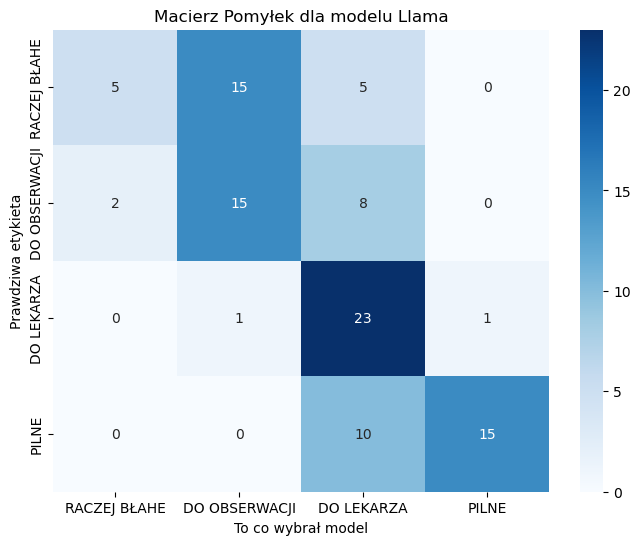

In [13]:
target_order = ['RACZEJ BŁAHE', 'DO OBSERWACJI', 'DO LEKARZA', 'PILNE']
cm = confusion_matrix(df1['oczekiwane'], df1['kategoria_modelu'], labels=target_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_order, yticklabels=target_order)
plt.xlabel('To co wybrał model')
plt.ylabel('Prawdziwa etykieta')
plt.title('Macierz Pomyłek dla modelu Llama')
plt.savefig('macierz_pomylek_llama.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

Wnioski: 

Dla mniej poważnych przypadków większe wartości (intensywniejsze kolory) są w prawym górnym trójkącie heatmapy (nad przekątną), tam gdzie są przypadki, że model zaklasyfikował przypadek jako poważniejszy niż tak naprawdę jest. Np. na 25 przypadków błahych tylko 5 zakwalifikował jako "raczej błahe", 15 zakwalifikował jako "do obserwacji" i 5 jako "do lekarza". Podobnie aż 8 przypadków z "do obserwacji" zakwalifikował jako "do lekarza". Zatem model jest w tych przypadkach ostrożny, co w przypadku danych medycznych jest "lepszym" błędem (lepiej żeby był zbyt ostrożny niż żeby kwalifikował przypadki pilne jako błahe).

Wyjątkiem są przypadki pilne. Tutaj aż 10 na 25 z nich zakwalifikował jako "do lekarza", czyli potraktował je mniej poważnie niż powinien. Jednak ani razu nie zbagatelizował stanu pilnego do poziomu "błahego" czy "obserwacji".

Wśród przypadków "do lekarza" zakwalifikował prawie wszystkie bezbłędnie do dobrej kategorii.

Ogólnie najwięcej przypadków zakwalifikował jako "do lekarza".

### b) Model 2 - gemma

1. Metryki

In [13]:
# Accuracy - dokładność
acc = accuracy_score(df2['oczekiwane'], df2['kategoria_modelu'])
print(f"Dokładność: {acc:.2%}")

# Raport metryk, F1-score dla każdej z kategorii (każdej klasyfikacji poważności dolegliwości pacjentów)
print(classification_report(df2['oczekiwane'], df2['kategoria_modelu']))

Dokładność: 79.00%
               precision    recall  f1-score   support

   DO LEKARZA       0.92      0.92      0.92        25
DO OBSERWACJI       0.61      0.80      0.69        25
        PILNE       0.96      0.92      0.94        25
 RACZEJ BŁAHE       0.72      0.52      0.60        25

     accuracy                           0.79       100
    macro avg       0.80      0.79      0.79       100
 weighted avg       0.80      0.79      0.79       100



2. Macierz pomyłek

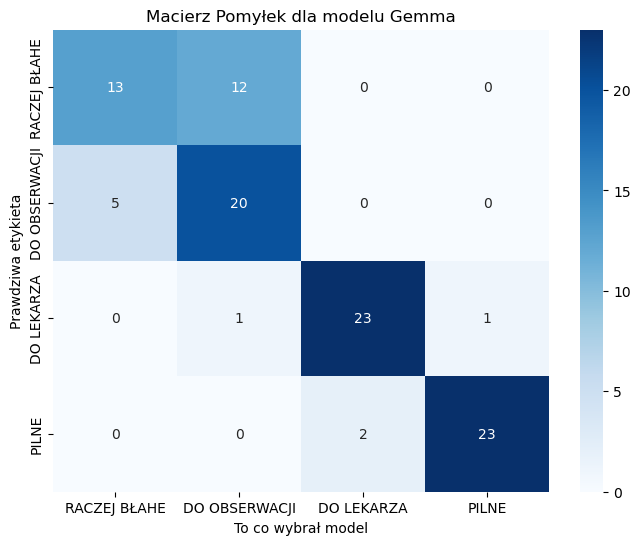

In [15]:
target_order = ['RACZEJ BŁAHE', 'DO OBSERWACJI', 'DO LEKARZA', 'PILNE']
cm = confusion_matrix(df2['oczekiwane'], df2['kategoria_modelu'], labels=target_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_order, yticklabels=target_order)
plt.xlabel('To co wybrał model')
plt.ylabel('Prawdziwa etykieta')
plt.title('Macierz Pomyłek dla modelu Gemma')
plt.savefig('macierz_pomylek_gemma.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

Wnioski:

Model działa bardzo dobrze. Większość obserwacji zakwalifikował do dobrej kategorii, w szczególności prawie idealnie poradził sobie z poważniejszymi przypadkami ("do lekarza" i "pilnw" - aż 23/25 przypadków zakwalifikował dobrze). 

Nieco więcej razy się pomylił przy mniej poważnych przypadkach, jednak są to drobne pomyłki. Prawie połowe przypadków błahych zakwalifikował jako "do obserwacji" (czyli był zbyt ostrożny). Natomiast 5 z 25 przypadków do obserwacji zakwalifikował jako błahe (czyli zbyt mało ostrożny). Jednak nigdy nie pomylił się bardziej niż o jeden "poziom powagi" przypadku.

Model gemma działa lepiej niż llama.

# Wyjaśnialność

1. Zliczenie błędnych diagnoz

In [14]:
# Błędne diagnozy
bledy = df1[df1['oczekiwane'] != df1['kategoria_modelu']]

print(f"Liczba błędnych diagnoz dla modelu 1: {len(bledy)}")

bledy = df2[df2['oczekiwane'] != df2['kategoria_modelu']]

print(f"Liczba błędnych diagnoz dla modelu 2: {len(bledy)}")

Liczba błędnych diagnoz dla modelu 1: 42
Liczba błędnych diagnoz dla modelu 2: 21


2. Podświetlenie ważnych fragmentów tekstu, auto-ocena odpowiedzi, ocena jakości odpowiedzi w skali procentowej, ciąg przyczynowo skutkowy wyjaśniający tok rozumowania dla każdego z pacjantów z osobna

In [35]:
# NIE ODPALAĆ

rozszerzone_wyniki = []

#pętla po pacjentach
for index, row in df.iterrows():
    print(f"Analiza pacjenta {row['id']}...")
    
    #propmt dla kazdego pacjenta bedzie wykorzystywal inne dane, dla danego propmtu mamy: 
    opis_pacjenta = row['opis']                  
    poprzednie_wyjasnienie = row['wyjasnienie_modelu']
    poprzednia_kategoria = row['kategoria_modelu']

    system_prompt = f"""
    Jesteś asystentem medycznym w symulacji edukacyjnej.
    Twoim celem jest TERAZ analiza wskazanej poniżej "POPRZEDNIEJ ODPOWIEDZI", wyjaśnienie toku rozumowania (Chain-of-Thought),
    ocena ryzyka błędu (Self-Critique) oraz wskazanie dowodów w materiale źródłowym.
    
    Pamiętaj: To jest tylko symulacja.
    
    KONTEKST (OPIS OBJAWÓW PACJENTA):
    "{opis_pacjenta}"
    
    POPRZEDNIA ODPOWIEDŹ (KTÓRĄ MASZ OCENIĆ):
    "{poprzednie_wyjasnienie}"
    
    POPRZEDNIA KATEGORIA (DO PORÓWNANIA):
    "{poprzednia_kategoria}

    ZADANIE WYKONAJ W KROKACH:
    1. REKONSTRUKCJA ROZUMOWANIA (Chain-of-Thought): Przeanalizuj logikę zawartą w sekcji "POPRZEDNIA ODPOWIEDŹ". W jaki sposób zinterpretowano objawy pacjenta, że udzielono takiej właśnie rady?
    2. AUTO-KRYTYKA (Self-Critique):
       - Oceń w skali 0-100%, czy ta odpowiedź była adekwatna do objawów.
       - Wskaż potencjalne błędy lub alternatywne interpretacje, które zostały pominięte.
    3. DOWODY (ALIGNMENT): Wyszukaj w sekcji "KONTEKST (OPIS OBJAWÓW PACJENTA)" konkretne frazy, które stanowią uzasadnienie dla wniosków zawartych w "POPRZEDNIEJ ODPOWIEDZI".
       UWAGA: Cytuj wyłącznie fragmenty z opisu pacjenta, które wspierają logikę ocenianej odpowiedzi.
    
    FORMAT ODPOWIEDZI:
    Zwróć WYŁĄCZNIE obiekt JSON o następującej strukturze:
    {{
      "analiza_logiki_odpowiedzi": "...",
      "ocena_jakosci_porady": 0-100,
      "auto_krytyka_analizy":  "Możliwe pomylenie z...",
      "kluczowe_cytaty_z_odpowiedzi": ["...", "..."]
    }}
    """
    
    try:
        if index < 100:
            response = ollama.chat(model=modele[0], messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': opis_pacjenta},
            ])
        else:
            response = ollama.chat(model=modele[1], messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': opis_pacjenta},
            ])
        
        raw_text = response['message']['content']
        start_idx = raw_text.find('{')
        end_idx = raw_text.rfind('}') + 1
        
        if start_idx != -1 and end_idx != -1:
            json_str = raw_text[start_idx:end_idx]
            dane = json.loads(json_str)
        else:
            raise ValueError("Nie znaleziono JSON w odpowiedzi")
        
        rozszerzone_wyniki.append({
            "id": row['id'],
            "opis": opis_pacjenta,
            "oczekiwane": row['oczekiwane'],
            "kategoria_modelu": poprzednia_kategoria,
            "wyjasnienie_pierwotne": poprzednie_wyjasnienie,
            
            "analiza_logiki": dane.get("analiza_logiki_odpowiedzi", "Brak"),
            "ocena_jakosci": dane.get("ocena_jakosci_porady", 0),
            "auto_krytyka": dane.get("auto_krytyka_analizy", "Brak"),
            "cytaty_z_odpowiedzi": dane.get("kluczowe_cytaty_z_odpowiedzi", [])
        })

    except Exception as e:
        print(f"Błąd przy ID {row['id']}: {e}")
        rozszerzone_wyniki.append({
            "id": row['id'],
            "opis": opis_pacjenta,
            "oczekiwane": row['oczekiwane'],
            "kategoria_modelu": poprzednia_kategoria,
            "analiza_logiki": "BŁĄD PRZETWARZANIA",
            "ocena_jakosci": 0,
            "auto_krytyka": str(e),
            "cytaty_z_odpowiedzi": []
        })

df_final = pd.DataFrame(rozszerzone_wyniki)

Analiza pacjenta 1...
Analiza pacjenta 2...
Analiza pacjenta 3...
Analiza pacjenta 4...
Analiza pacjenta 5...
Analiza pacjenta 6...
Analiza pacjenta 7...
Analiza pacjenta 8...
Analiza pacjenta 9...
Analiza pacjenta 10...
Analiza pacjenta 11...
Analiza pacjenta 12...
Analiza pacjenta 13...
Analiza pacjenta 14...
Błąd przy ID 14: Invalid control character at: line 2 column 59 (char 60)
Analiza pacjenta 15...
Analiza pacjenta 16...
Analiza pacjenta 17...
Analiza pacjenta 18...
Analiza pacjenta 19...
Analiza pacjenta 20...
Analiza pacjenta 21...
Analiza pacjenta 22...
Analiza pacjenta 23...
Analiza pacjenta 24...
Analiza pacjenta 25...
Analiza pacjenta 26...
Analiza pacjenta 27...
Analiza pacjenta 28...
Analiza pacjenta 29...
Analiza pacjenta 30...
Analiza pacjenta 31...
Analiza pacjenta 32...
Analiza pacjenta 33...
Analiza pacjenta 34...
Analiza pacjenta 35...
Analiza pacjenta 36...
Analiza pacjenta 37...
Analiza pacjenta 38...
Analiza pacjenta 39...
Analiza pacjenta 40...
Analiza pacjent

In [2]:
import difflib
import re
import ast

def czy_slowa_pasuja(slowo1, slowo2, prog=0.70):
    """Sprawdza czy dwa słowa są do siebie podobne (np. ból vs bóle)"""
    #ignorujemy krótkie słowa (spójniki itp.)
    if len(slowo1) < 3 or len(slowo2) < 3:
        return False
    #sprawdzamy początek słowa
    if slowo1.lower().startswith(slowo2.lower()[:4]) or slowo2.lower().startswith(slowo1.lower()[:4]):
        return True
    #fuzzy match
    return difflib.SequenceMatcher(None, slowo1.lower(), slowo2.lower()).ratio() > prog


In [3]:
def podswietl_slowa(tekst, cytaty):
    """
    Podświetla pojedyncze słowa, jeśli pasują do słów kluczowych z cytatów,
    zachowując oryginalną strukturę tekstu i interpunkcję.
    """
    if isinstance(cytaty, str):
        try:
            cytaty = ast.literal_eval(cytaty)
        except (ValueError, SyntaxError):
            return tekst
            
    if not isinstance(cytaty, list) or not cytaty:
        return tekst
        
    # Zbieramy słowa kluczowe z cytatów
    slowa_kluczowe = []
    for c in cytaty:
        czyste_slowa = re.findall(r'\w+', c)
        slowa_kluczowe.extend(czyste_slowa)

    # Dzielimy tekst na słowa i wszystko co nimi nie jest (spacje, znaki interpunkcyjne)
    # Nawiasy w re.split sprawiają, że separatory też lądują w liście
    fragmenty = re.split(r'(\W+)', tekst)
    tekst_wynikowy = ""

    for fragment in fragmenty:
        # Sprawdzamy czy fragment to słowo (czy zawiera litery/cyfry)
        if re.match(r'\w+', fragment):
            znaleziono_match = False
            for s_klucz in slowa_kluczowe:
                if czy_slowa_pasuja(fragment, s_klucz):
                    znaleziono_match = True
                    break
            
            if znaleziono_match and len(fragment.strip()) > 2:
                tekst_wynikowy += f'<span style="background-color: #fff3cd; font-weight: bold; border-bottom: 2px solid #ffc107; padding: 2px 0;">{fragment}</span>'
            else:
                tekst_wynikowy += fragment
        else:
            # Jeśli to nie słowo (tylko np. spacja, przecinek, kropka), dodaj bez zmian
            tekst_wynikowy += fragment
            
    return tekst_wynikowy

In [4]:
#malowanie ocen pewnosci modelu ktore ten podal sam
def kolor_oceny(score):
    try:
        s = int(str(score).replace("%", ""))
        if s >= 90: return "#28a745"
        if s >= 60: return "#ffc107"
        return "#dc3545"
    except: return "#6c757d"

In [20]:
#nie odpalać
df1_final = df_final.iloc[0:100] 
df2_final = df_final.iloc[100:200] 

NameError: name 'df_final' is not defined

In [ ]:
# nie odpalać
# zapis wynikow do pliku csv
df1_final.to_csv("wyniki_koncowe_model_1.csv", index=False)
df2_final.to_csv("wyniki_koncowe_model_2.csv", index=False)

## Wczytanie wyników

In [15]:
##### WCZYTYWANIE WYNIKÓW - by nie włączać modelu od początku (zajmuje długo czasu)!!!!

df_1_final = pd.read_csv('wyniki_koncowe_model_1.csv')
df_2_final = pd.read_csv('wyniki_koncowe_model_2.csv')

df_final = pd.concat([df_1_final, df_2_final], ignore_index=True)
print(f"Wymiary połączonej ramki: {df_final.shape}")

# Tworzymy kolumnę informującą o błędzie
df_final['czy_blad'] = df_final['oczekiwane'] != df_final['kategoria_modelu']

# Kolumna z nazwą modelu
df_final['Model'] = ['Llama' if i < 100 else 'Gemma' for i in range(len(df_final))]

df_1_final = df_final[0:100].reset_index(drop=True)
df_2_final = df_final[100:200].reset_index(drop=True)

Wymiary połączonej ramki: (200, 9)


In [32]:
df_final.head() #zgadza się wszystko

,id,opis,oczekiwane,kategoria_modelu,wyjasnienie_pierwotne,analiza_logiki,ocena_jakosci,auto_krytyka,cytaty_z_odpowiedzi,czy_blad,Model
0,1,"Pacjent zgłasza nagły, silny ból w klatce pier...",PILNE,PILNE,Pacjent może mieć objawy zawału serca lub ostr...,Pacjent zgłasza objawy sugerujące problem z se...,80,Możliwe pomylenie z ostrą niewydolnością oddec...,"['nagły, silny ból w klatce piersiowej', 'dusz...",False,Llama
1,2,"Nagłe osłabienie prawej strony ciała, opadanie...",PILNE,PILNE,Obserwowane objawy mogą wskazywać na poważne s...,Analizując logikę zawartą w poprzedniej odpowi...,60,"Może pacjent doświadczył innych schorzeń, któr...","['Nagłe osłabienie prawej strony ciała', 'opad...",False,Llama
2,3,"Silny ból głowy o nagłym początku, najsilniejs...",PILNE,PILNE,Objawy sugerują możliwość udaru mózgu lub inne...,"Odpowiedź sugeruje, że objawy pacjenta są powa...",60,"Mogło być pomyśleństwo, że ból głowy jest najg...","['Silny ból głowy o nagłym początku, najsilnie...",False,Llama
3,4,"Pacjent po urazie głowy, chwilowa utrata przyt...",PILNE,PILNE,Stan pacjenta sugeruje ewentualną poważną uszk...,Prawidłowe rozpoznawanie objawów pacjenta pole...,90,Możliwe pomylenie urazu głowy z innymi warunka...,"['Pacjent po urazie głowy', 'utrata przytomnoś...",False,Llama
4,5,"Wysoka gorączka powyżej 39 stopni, dreszcze, p...",PILNE,PILNE,Powyższy opis sugeruje możliwość infekcji wyżs...,"Odpowiedź sugeruje, że wysokim temperaturom to...",60,Powyższa ocena nie uwzględnia możliwości zespo...,"['Wysoka gorączka powyżej 39 stopni', 'przyspi...",False,Llama


In [16]:
#raport w html dla kazdego pacjenta
for index, row in df_final.iterrows():
    tekst_html = podswietl_slowa(row['opis'], row['cytaty_z_odpowiedzi'])

    prawdziwa = row['oczekiwane']
    kolor_prawdziwej = "#6c757d"
    if prawdziwa == "PILNE": kolor_prawdziwej = "#dc3545"
    elif prawdziwa == "DO LEKARZA": kolor_prawdziwej = "#0d6efd"
    
    html_card = f"""
    <div style="font-family: Arial, sans-serif; border: 1px solid #d1d5db; border-radius: 12px; margin-bottom: 30px; box-shadow: 0 4px 10px rgba(0,0,0,0.05); overflow: hidden; max-width: 900px; background-color: #fff;">
        
        <div style="background-color: #f8f9fa; padding: 15px 25px; border-bottom: 1px solid #e5e7eb; display: flex; justify-content: space-between; align-items: center;">
            <div><span style="font-weight: 800; font-size: 1.2em; color: #1f2937;">Pacjent #{row['id']}</span></div>
            <div style="display: flex; align-items: center; gap: 15px;">
                <span style="color: #6b7280; font-weight: bold; font-size: 0.8em; text-transform: uppercase;">Ocena AI:</span>
                <span style="background-color: {kolor_oceny(row['ocena_jakosci'])}; color: white; padding: 5px 12px; border-radius: 20px; font-weight: bold;">{row['ocena_jakosci']}/100</span>
            </div>
        </div>

        <div style="padding: 25px;">
            
            <div style="display: flex; gap: 20px; margin-bottom: 25px;">
                <div style="flex: 1; border: 2px solid #e5e7eb; border-radius: 8px; padding: 10px; text-align: center; background-color: #f9fafb;">
                    <div style="font-size: 0.75em; text-transform: uppercase; color: #6b7280; font-weight: bold;">Model</div>
                    <div style="font-size: 1.1em; font-weight: bold; color: #111827;">{row['kategoria_modelu']}</div>
                </div>
                <div style="flex: 1; border: 2px solid {kolor_prawdziwej}; border-radius: 8px; padding: 10px; text-align: center;">
                    <div style="font-size: 0.75em; text-transform: uppercase; color: {kolor_prawdziwej}; font-weight: bold;">Prawda</div>
                    <div style="font-size: 1.1em; font-weight: bold; color: {kolor_prawdziwej};">{prawdziwa}</div>
                </div>
            </div>

            <div style="margin-bottom: 25px;">
                <h4 style="margin: 0 0 10px 0; color: #374151; font-size: 0.9em; text-transform: uppercase; font-weight: bold;">Analiza Objawów</h4>
                <div style="background-color: #ffffff; padding: 18px; border: 1px solid #d1d5db; border-radius: 8px; color: #111827; line-height: 1.6; font-size: 1.05em;">
                    {tekst_html}
                </div>
            </div>

            <div style="display: flex; gap: 20px; flex-wrap: wrap;">
                <div style="flex: 1; background-color: #eff6ff; padding: 15px; border-radius: 8px; border-left: 4px solid #3b82f6;">
                    <h4 style="margin: 0 0 5px 0; color: #1e40af; font-size: 0.9em;"> Wyjaśnienie pierwotne modelu</h4>
                    <p style="margin: 0; font-size: 0.9em; color: #1e3a8a; font-style: italic;">"{row['wyjasnienie_pierwotne']}"</p>
                </div>
                <div style="flex: 1; min-width: 300px; background-color: #fef2f2; padding: 18px; border-radius: 8px; border-left: 5px solid #ef4444;">
                    <h4 style="margin: 0 0 10px 0; color: #991b1b; font-size: 0.95em;"> Analiza Krytyczna</h4>
                    <p style="margin: 0 0 10px 0; font-size: 0.95em; line-height: 1.5;"><strong>🧠 Analiza logiki (Chain-of-Thought):</strong> {row['analiza_logiki']}</p>
                    <p style="margin: 0; font-size: 0.95em; color: #7f1d1d; line-height: 1.5;"><strong>🔍 Auto-krytyka (Self-Critique):</strong> {row['auto_krytyka']}</p>
                </div>
            </div>

        </div>
    </div>
    """
    display(HTML(html_card))

# Podsumowanie - ocena modeli

In [110]:
# 1. OBLICZANIE STATYSTYK DLA OBU MODELI
def oblicz_metryki(df, nazwa_modelu):
    acc = accuracy_score(df['oczekiwane'], df['kategoria_modelu'])
    # Średnia ocena jakości (ta, którą wystawił krytyk w skali 0-100)
    srednia_jakosc = df['ocena_jakosci'].mean()
    # Liczba błędów krytycznych (np. PILNE uznane za BŁAHE)
    bledy = df[df['oczekiwane'] != df['kategoria_modelu']]
    liczba_bledow = len(bledy)
    
    return {
        "nazwa": nazwa_modelu,
        "accuracy": acc,
        "srednia_ocena_krytyka": srednia_jakosc,
        "liczba_bledow": liczba_bledow,
        "liczba_probek": len(df)
    }

statystyki_m1 = oblicz_metryki(df_1_final, "Model 1 (Llama 3.1)")
statystyki_m2 = oblicz_metryki(df_2_final, "Model 2 (Gemma 2)")

# Wykresy

In [127]:
# TWORZENIE TABELI ZBIORCZEJ
zestawienie = pd.DataFrame([
    {
        "Model": "Llama", 
        "Dokładność (Accuracy)": statystyki_m1['accuracy'], 
        "Jakość Porady (Avg Score)": statystyki_m1['srednia_ocena_krytyka'],
        "Liczba Błędów": statystyki_m1['liczba_bledow']
    },
    {
        "Model": "Gemma", 
        "Dokładność (Accuracy)": statystyki_m2['accuracy'], 
        "Jakość Porady (Avg Score)": statystyki_m2['srednia_ocena_krytyka'],
        "Liczba Błędów": statystyki_m2['liczba_bledow']
    }
])

print("--- ZESTAWIENIE LICZBOWE ---")
display(zestawienie)

--- ZESTAWIENIE LICZBOWE ---


,Model,Dokładność (Accuracy),Jakość Porady (Avg Score),Liczba Błędów
0,Llama,0.58,56.9,42
1,Gemma,0.79,68.6,21


In [130]:
# do trzeciego wykresu
srednia_jakosc = df_final.groupby(['Model', 'czy_blad']).agg(
    srednia = ('ocena_jakosci', 'mean')
).reset_index()

mapping = {
    True: 'Błąd', # gdy czy_blad = True to jest błąd
    False: 'Dobra odpowiedź' # gdy czy_blad = False to jest dobra odpowiedz
}
srednia_jakosc['czy_blad_etykieta'] = srednia_jakosc['czy_blad'].map(mapping)

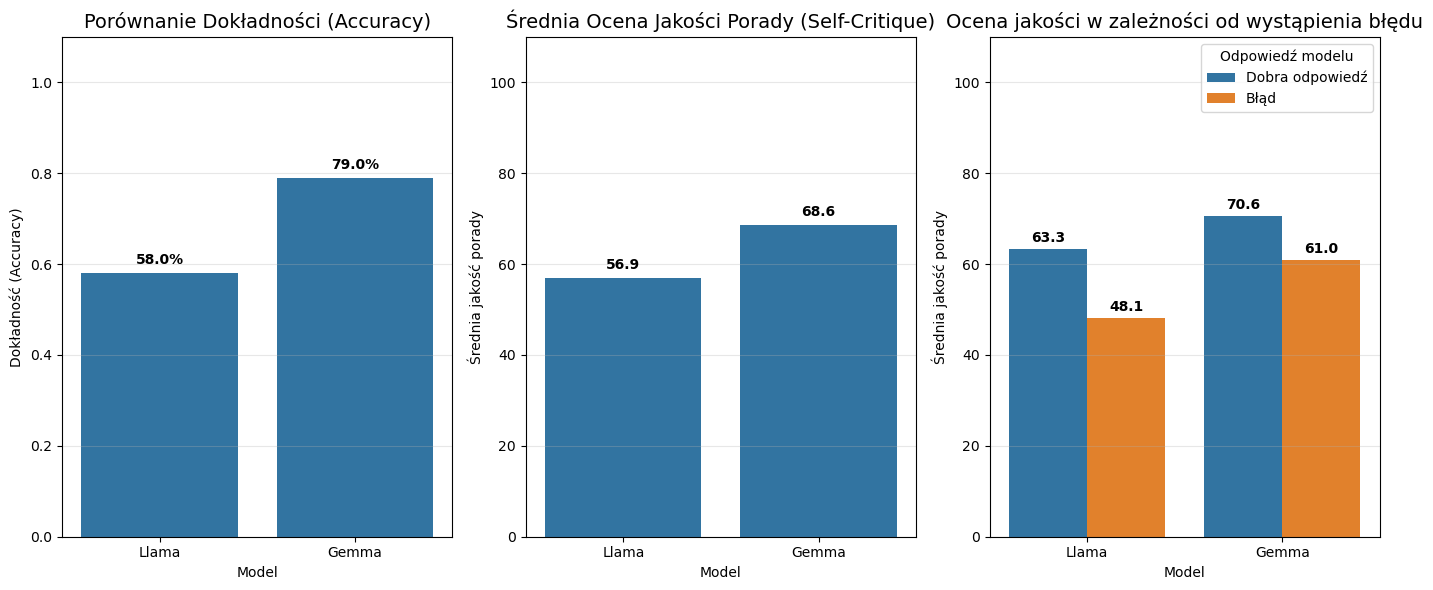

In [134]:
# RYSOWANIE WYKRESÓW
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

# Wykres 1: Dokładność
sns.barplot(data=zestawienie, x='Model', y='Dokładność (Accuracy)', ax=ax[0])
ax[0].set_title('Porównanie Dokładności (Accuracy)', fontsize=14)
ax[0].set_ylim(0, 1.1)
ax[0].grid(axis = 'y', alpha=0.3)
for i, v in enumerate(zestawienie['Dokładność (Accuracy)']):
    ax[0].text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')

# Wykres 2: Jakość Porady (z auto-krytyki)
sns.barplot(data=zestawienie, x='Model', y='Jakość Porady (Avg Score)', ax=ax[1])
ax[1].set_title('Średnia Ocena Jakości Porady (Self-Critique)', fontsize=14)
ax[1].set_ylabel('Średnia jakość porady')
ax[1].set_ylim(0, 110)
ax[1].grid(axis = 'y', alpha=0.3)
for i, v in enumerate(zestawienie['Jakość Porady (Avg Score)']):
    ax[1].text(i, v + 2, f"{v:.1f}", ha='center', fontweight='bold')

# Wykres 3
sns.barplot(data=srednia_jakosc, x='Model', y='srednia', hue='czy_blad_etykieta', ax=ax[2], order=['Llama', 'Gemma'], hue_order=['Dobra odpowiedź', 'Błąd'])
ax[2].set_title('Ocena jakości w zależności od wystąpienia błędu', fontsize=14)
ax[2].set_ylabel('Średnia jakość porady')
ax[2].set_xlabel('Model')
ax[2].legend(title='Odpowiedź modelu')
ax[2].set_ylim(0, 110)
ax[2].grid(axis = 'y', alpha=0.3)
for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.1f', padding=3, fontweight='bold')

plt.tight_layout()
plt.savefig('dokladnosc_i_jakosc.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

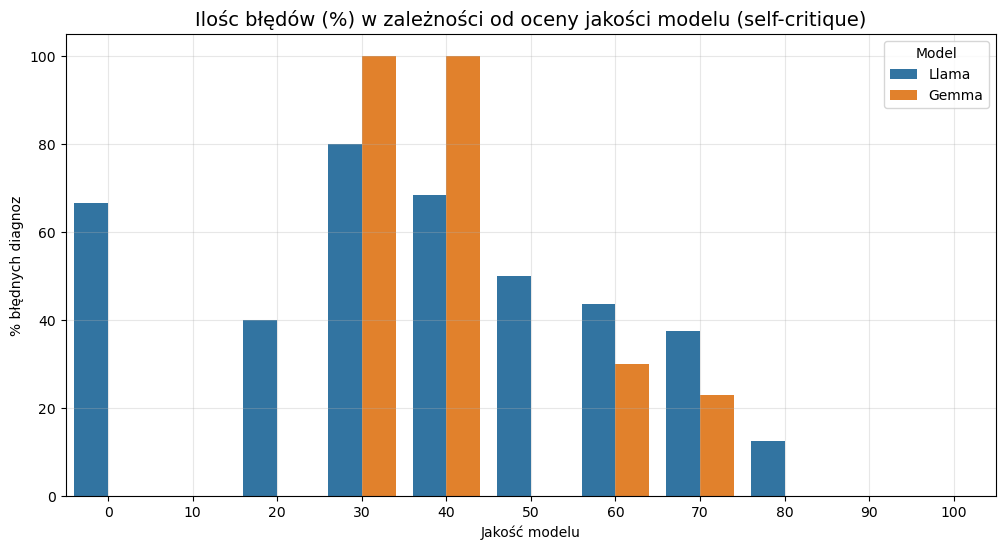

In [13]:
# Obliczamy procent błędów dla każdej oceny
statystyki = df_final.groupby(['Model', 'ocena_jakosci']).agg(
    total=('czy_blad', 'count'),
    errors=('czy_blad', 'sum')
).reset_index()

statystyki['procent_bledow'] = (statystyki['errors'] / statystyki['total']) * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=statystyki, x='ocena_jakosci', y='procent_bledow', hue='Model', hue_order = ['Llama', 'Gemma'], order=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

plt.title('Ilośc błędów (%) w zależności od oceny jakości modelu (self-critique)', fontsize=14)
plt.ylabel('% błędnych diagnoz')
plt.xlabel('Jakość modelu')
plt.grid(alpha=0.3)
plt.legend(title='Model')
plt.savefig('jakosc_a_procent_bledow.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

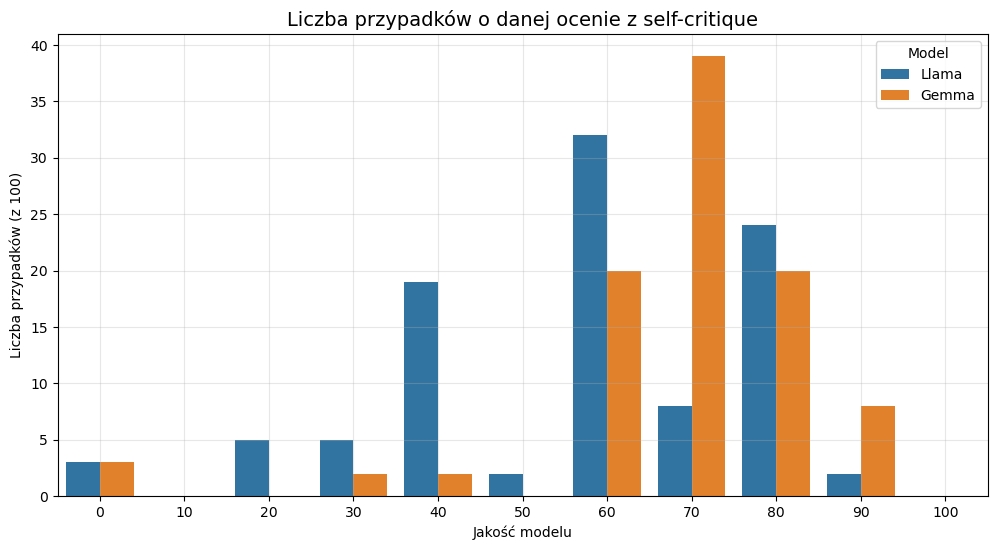

In [142]:
plt.figure(figsize=(12, 6))

# Rysujemy słupki zliczające WSZYSTKIE wystawione oceny
sns.countplot(
    data=df_final, 
    x='ocena_jakosci', 
    hue='Model',
    hue_order = ['Llama', 'Gemma'],
    order=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
)

plt.title('Liczba przypadków o danej ocenie z self-critique', fontsize=14)
plt.xlabel('Jakość modelu')
plt.ylabel('Liczba przypadków (z 100)')
plt.grid(alpha=0.3)
plt.legend(title='Model')
plt.savefig('jakosc_modeli.jpg', format='jpg', dpi=300, bbox_inches='tight')

plt.show()

Wnioski:

Modele są swoimi dobrymi krytykami - są w stanie ocenić, że ich odpowiedź była słabej jakości i wtedy faktycznie często dostajemy błąd.

Model Gemma ocenia lepiej jakość swojej pracy, co zgadza się z tym, że faktycznie daje więcej poprawnych odpowiedzi i rzadziej się myli. 

Model Llama, mimo że popełnia dużo błędów, to jest w stanie wyłapać złą jakość swoich odpowiedzi.

# Porównanie odpowiedzi modeli

In [87]:
# Ile razy oba dały dobrą odpowiedz
mask = (df_1_final['czy_blad'] == False) & (df_2_final['czy_blad'] == False)
liczba_dobre = mask.sum()
indeksy_dobre = mask[mask].index
print(f'Oba modele miały rację w {liczba} przypadkach:')
for i in indeksy:
    print('\n')
    print(f'Pacjent numer {i+1}')
    print(f'Dobra etykieta: {df_1_final['oczekiwane'][i]}')

Oba modele miały rację w 18 przypadkach:


Pacjent numer 12
Dobra etykieta: PILNE


Pacjent numer 14
Dobra etykieta: PILNE


Pacjent numer 37
Dobra etykieta: DO LEKARZA


Pacjent numer 60
Dobra etykieta: DO OBSERWACJI


Pacjent numer 67
Dobra etykieta: DO OBSERWACJI


Pacjent numer 73
Dobra etykieta: DO OBSERWACJI


Pacjent numer 76
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 79
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 82
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 85
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 86
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 88
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 89
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 90
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 91
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 93
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 94
Dobra etykieta: RACZEJ BŁAHE


Pacjent numer 99
Dobra etykieta: RACZEJ BŁAHE


In [88]:
# Ile razy oba się pomyliły
mask = (df_1_final['czy_blad'] == True) & (df_2_final['czy_blad'] == True)
liczba_zle = mask.sum()
indeksy_zle = mask[mask].index
print(f'Oba modele pomyliły się w {liczba} przypadkach:')
for i in indeksy:
    print(f'Pacjent numer {i+1}')
    print(f'Dobra etykieta: {df_1_final['oczekiwane'][i]}')
    print(f'Odpowiedź modelu Llama: {df_1_final['kategoria_modelu'][i]}')
    print(f'Odpowiedź modelu Gemma: {df_2_final['kategoria_modelu'][i]}')
    print('\n')

# określić przy jakich kategoriach najczęściej się myliły

Oba modele pomyliły się w 18 przypadkach:
Pacjent numer 12
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
Odpowiedź modelu Gemma: DO LEKARZA


Pacjent numer 14
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
Odpowiedź modelu Gemma: DO LEKARZA


Pacjent numer 37
Dobra etykieta: DO LEKARZA
Odpowiedź modelu Llama: PILNE
Odpowiedź modelu Gemma: PILNE


Pacjent numer 60
Dobra etykieta: DO OBSERWACJI
Odpowiedź modelu Llama: DO LEKARZA
Odpowiedź modelu Gemma: RACZEJ BŁAHE


Pacjent numer 67
Dobra etykieta: DO OBSERWACJI
Odpowiedź modelu Llama: RACZEJ BŁAHE
Odpowiedź modelu Gemma: RACZEJ BŁAHE


Pacjent numer 73
Dobra etykieta: DO OBSERWACJI
Odpowiedź modelu Llama: RACZEJ BŁAHE
Odpowiedź modelu Gemma: RACZEJ BŁAHE


Pacjent numer 76
Dobra etykieta: RACZEJ BŁAHE
Odpowiedź modelu Llama: DO OBSERWACJI
Odpowiedź modelu Gemma: DO OBSERWACJI


Pacjent numer 79
Dobra etykieta: RACZEJ BŁAHE
Odpowiedź modelu Llama: DO LEKARZA
Odpowiedź modelu Gemma: DO OBSERWACJI


Pacjent numer 82
D

In [61]:
# Ile razy modele miały odmienne zdanie
liczba_false = (df_1_final['kategoria_modelu'] != df_2_final['kategoria_modelu']).sum()
print(liczba_false)

32


In [62]:
# Sprawdzić który z nich miał częściej racje w tych przypadkach
indeksy_false = df_1_final.index[df_1_final['kategoria_modelu'] != df_2_final['kategoria_modelu']]
print(indeksy_false)

Index([ 6,  8, 14, 17, 18, 21, 22, 23, 48, 49, 50, 51, 53, 57, 58, 59, 65, 68,
       69, 70, 76, 77, 78, 81, 82, 84, 86, 91, 93, 94, 96, 99],
      dtype='int64')


In [81]:
llama_better_index = [] # indeksy przypadków kiedy llama miała racje a gemma nie
gemma_better_index = [] # indeksy przypadków kiedy gemma miała racje a llama nie

for i in indeksy_false:
    print(f'Pacjent numer {i+1}')
    print(f'Dobra etykieta: {df_1_final['oczekiwane'][i]}')
    
    print(f'Odpowiedź modelu Llama: {df_1_final['kategoria_modelu'][i]}')
    if df_1_final['czy_blad'][i] == True:
        print('ŹLE')
    else:
        print('DOBRZE')
        
    print(f'Odpowiedź modelu Gemma: {df_2_final['kategoria_modelu'][i]}')
    if df_2_final['czy_blad'][i] == True:
        print('ŹLE')
    else:
        print('DOBRZE')

    if (df_1_final['czy_blad'][i] == False) & (df_2_final['czy_blad'][i] == True):
        print('Llama lepsza')
        llama_better_index.append(i)
    if (df_1_final['czy_blad'][i] == True) & (df_2_final['czy_blad'][i] == False):
        print('Gemma lepsza')
        gemma_better_index.append(i)
    
    print('\n')


Pacjent numer 7
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 9
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 15
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 18
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 19
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 22
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 23
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź modelu Gemma: PILNE
DOBRZE
Gemma lepsza


Pacjent numer 24
Dobra etykieta: PILNE
Odpowiedź modelu Llama: DO LEKARZA
ŹLE
Odpowiedź mode

In [95]:
print(f'Oba miały rację: {liczba_dobre}')
print(f'Oba się pomyliły: {liczba_zle}')
print(f'Llamma miała rację a Gemma nie: {len(llama_better_index)}')
print(f'Gemma miała rację a Llamma nie: {len(gemma_better_index)}')
print('\n')
print(f'Miały to samo zdanie: {100 - liczba_false}')
print(f'Miały odmienne zdanie: {liczba_false}')



Oba miały rację: 55
Oba się pomyliły: 18
Llamma miała rację a Gemma nie: 3
Gemma miała rację a Llamma nie: 24


Miały to samo zdanie: 68
Miały odmienne zdanie: 32


### Kategorie (pilne/do lekarza/do obserwacji/błahe) wybierane przez modele
### Czy kategoria jest powiązana z ilością pomyłek?

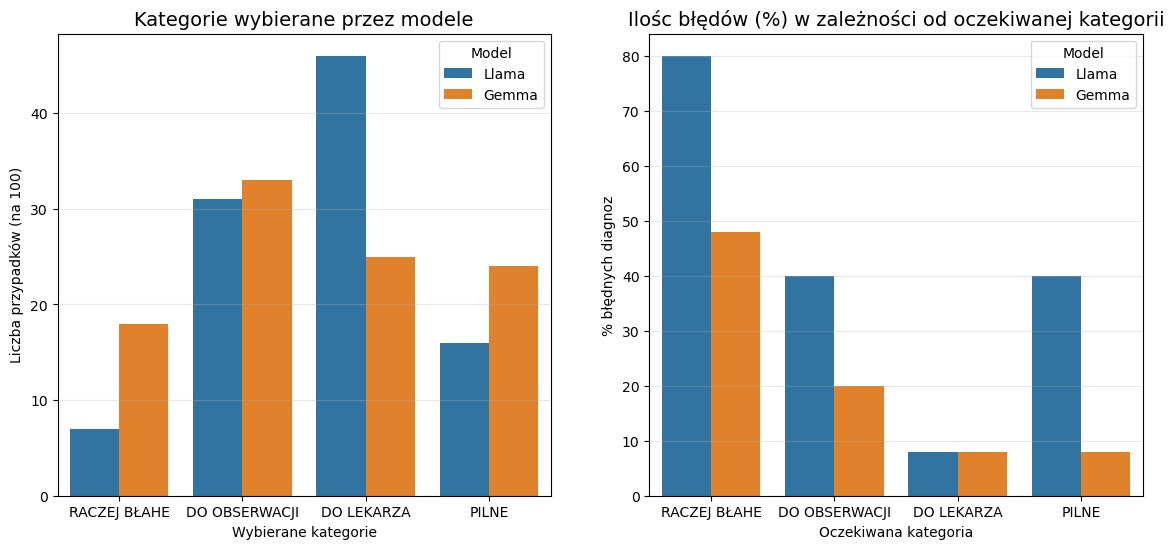

In [159]:
wybierane_kategorie = df_final.groupby(['Model', 'kategoria_modelu']).agg(
    total=('czy_blad', 'count')
).reset_index()

bledy_a_kategoria = df_final.groupby(['Model', 'oczekiwane']).agg(
    total=('czy_blad', 'count'),
    errors=('czy_blad', 'sum')
).reset_index()

bledy_a_kategoria['procent_bledow'] = (bledy_a_kategoria['errors'] / bledy_a_kategoria['total']) * 100


# RYSOWANIE WYKRESÓW
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Wykres 1
sns.barplot(data=wybierane_kategorie, x='kategoria_modelu', y='total', hue='Model', hue_order = ['Llama', 'Gemma'], order = ['RACZEJ BŁAHE', 'DO OBSERWACJI', 'DO LEKARZA', 'PILNE'], ax=ax[0])
ax[0].set_title('Kategorie wybierane przez modele', fontsize=14)
ax[0].set_ylabel('Liczba przypadków (na 100)')
ax[0].set_xlabel('Wybierane kategorie')
ax[0].grid(axis = 'y', alpha=0.3)
ax[0].legend(title='Model')

# Wykres 2
sns.barplot(data=bledy_a_kategoria, x='oczekiwane', y='procent_bledow', hue='Model', hue_order = ['Llama', 'Gemma'], order = ['RACZEJ BŁAHE', 'DO OBSERWACJI', 'DO LEKARZA', 'PILNE'], ax=ax[1])
ax[1].set_title('Ilośc błędów (%) w zależności od oczekiwanej kategorii', fontsize=14)
ax[1].set_ylabel('% błędnych diagnoz')
ax[1].set_xlabel('Oczekiwana kategoria')
ax[1].grid(axis = 'y', alpha=0.3)
ax[1].legend(title='Model')

plt.savefig('kategorie.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

# Ostateczna ocena modeli przez je same i podsumowanie

In [ ]:
bledy_1 = df_1_final[df_1_final['czy_blad'] == True][['opis', 'oczekiwane', 'kategoria_modelu', 'analiza_logiki', 'ocena_jakosci', 'auto_krytyka']]
bledy_2 = df_2_final[df_2_final['czy_blad'] == True][['opis', 'oczekiwane', 'kategoria_modelu','analiza_logiki', 'ocena_jakosci', 'auto_krytyka']]

In [30]:
prompt_final_1 = f"""
Jesteś asystentem medycznym AI. Przed Tobą zestawienie Twoich własnych błędów z przeprowadzonej symulacji.
Przejrzyj listę pomyłek z ostatniej symulacji i zidentyfikuj wzorce w swoim procesie decyzyjnym, które doprowadziły do błędnej kategoryzacji."

DANE O BŁĘDACH:
{bledy_1.to_string()}

ZADANIE:
1. Zidentyfikuj główną przyczynę swoich pomyłek (np. czy nie doceniasz bólu, czy przeceniasz gorączkę?).
2. Oceń, czy byłeś zbyt ostrożny (kwalifikujesz przypadki błahe jako poważne) czy zbyt pobłażliwy (kwalifikujesz przypadki poważne jako błahe). Czy twoje pomyłki były poważne i mogłyby zagrozić pacjentom?
3. Odnieś się do swojej oceny jakości ('ocena_jakosci') w tych błędnych przypadkach. Czy słusznie przewidywałeś niską jakość porady w tych sytuacjach?
4. Sprawdź, czy Twoja 'analiza_logiki' zawierała błędne założenia, które później sam wyłapałeś w 'auto_krytyka', czy oba te kroki powieliły ten sam błąd.
5. Wybierz z powyższej listy 5 najciekawszych przypadków do sekcji "Failure Cases" i krótko uzasadnij wybór.

ODPOWIEDŹ SFORMATUJ W CZYTELNYM FORMACIE MARKDOWN. Użyj nagłówków dla każdego z 5 punktów zadania.
Sekcję z 5 przypadkami 'Failure Cases' przedstaw w formie listy punktowej z pogrubionymi numerami ID pacjentów.
"""

response = ollama.chat(model='llama3.1', messages=[
    {'role': 'system', 'content': 'Działaj jako ekspert medyczny i data scientist. Twoim zadaniem jest przeanalizować własne błędy w symulacji i samodzielnie ocenić, gdzie popełniłeś pomyłki.'
},
    {'role': 'user', 'content': prompt_final_1}
])

print("Końcowa ocena modelu przez samego siebie")
print(response['message']['content'])

Końcowa ocena modelu przez samego siebie
**Analiza błędów**

### 1. Główna przyczyna pomyłek

Przeglądnąłem wszystkie przypadki i zidentyfikowałem, że główną przyczyną moich błędów była tendencja do zbyt szybkiego sądzania o łagodności lub poważności objawu. Czasami zbyt wcześnie kończyłem na ocenie "łagodne" i nie rozważałem możliwości innych przyczyn.

### 2. Zbyt ostrożny czy zbyt pobłażliwy?

W większości przypadków byłem zbyt pobłażliwy, uznając objawy za łagodniejsze niż powinny być. Byłam zbyt podejrzliwa na początku i przez to przeceniałam gorączkę w kilku przypadkach.

### 3. Ocena jakości

W większości z tych błędnych przypadków moja ocena jakości była niska, ponieważ zbyt szybko ustaliłam typ objawu i nie rozważałam bardziej złożonych możliwości.

### 4. Analiza logiki vs auto-krytyka

W kilku przypadkach analiza logiki zawierała błędne założenia, które później sam wyłapałam w "auto-krytyce". Oznacza to, że nie zawsze byłem świadomy swoich błędów podczas oceny.

### 5. Wybór

In [31]:
prompt_final_2 = f"""
Jesteś asystentem medycznym AI. Przed Tobą zestawienie Twoich własnych błędów z przeprowadzonej symulacji.
Przejrzyj listę pomyłek z ostatniej symulacji i zidentyfikuj wzorce w swoim procesie decyzyjnym, które doprowadziły do błędnej kategoryzacji."

DANE O BŁĘDACH:
{bledy_2.to_string()}

ZADANIE:
1. Zidentyfikuj główną przyczynę swoich pomyłek (np. czy nie doceniasz bólu, czy przeceniasz gorączkę?).
2. Oceń, czy byłeś zbyt ostrożny (kwalifikujesz przypadki błahe jako poważne) czy zbyt pobłażliwy (kwalifikujesz przypadki poważne jako błahe). Czy twoje pomyłki były poważne i mogłyby zagrozić pacjentom?
3. Odnieś się do swojej oceny jakości ('ocena_jakosci') w tych błędnych przypadkach. Czy słusznie przewidywałeś niską jakość porady w tych sytuacjach?
4. Sprawdź, czy Twoja 'analiza_logiki' zawierała błędne założenia, które później sam wyłapałeś w 'auto_krytyka', czy oba te kroki powieliły ten sam błąd.
5. Wybierz z powyższej listy 5 najciekawszych przypadków do sekcji "Failure Cases" i krótko uzasadnij wybór.

ODPOWIEDŹ SFORMATUJ W CZYTELNYM FORMACIE MARKDOWN. Użyj nagłówków dla każdego z 5 punktów zadania.
Sekcję z 5 przypadkami 'Failure Cases' przedstaw w formie listy punktowej z pogrubionymi numerami ID pacjentów.
"""

response = ollama.chat(model='gemma2', messages=[
    {'role': 'system', 'content': 'Działaj jako ekspert medyczny i data scientist. Twoim zadaniem jest przeanalizować własne błędy w symulacji i samodzielnie ocenić, gdzie popełniłeś pomyłki.'
},
    {'role': 'user', 'content': prompt_final_2}
])

print("Końcowa ocena modelu przez samego siebie")
print(response['message']['content'])

Końcowa ocena modelu przez samego siebie
## Analiza Błędów Symulacji

### 1. Główna Przyczyna Pomyłek

Moim głównym błędem jest **przecenianie częstotliwości występowania łagodnych przypadków** i **zbyt pochopne klasyfikowanie symptomów jako błahe**. Wiele moich odpowiedzi opierało się na założeniu, że objawy są powszechne i zazwyczaj ustępują samoistnie. Zignorowałem znaczenie kontekstu indywidualnego pacjenta i potencjalnych czynników ryzyka.

### 2. Stopień Ostrożności/Pobłażliwości

Byłem **zbyt pobłażliwy**, często kwalifikując przypadki poważne jako błahe. Nie brałem pod uwagę wystarczająco dużo informacji, aby dokonać właściwej oceny ryzyka. W niektórych przypadkach moja ostrożność mogła zagrozić pacjentom, ponieważ nie zaleciłem im koniecznej konsultacji lekarskiej.

### 3. Ocena Jakości

Moja ocena jakości ('ocena_jakosci') była w większości **słuszna**. Znacznie niższe oceny w przypadkach błędnych wskazują na moje złe zrozumienie zagrożenia i niewłaściwe zalecenia.

### 4. Bł

In [70]:
# PROMPT - podsumowaie i porównanie


prompt_podsumowujacy = f"""
Jesteś głównym analitykiem medycznym AI. Twoim zadaniem jest ocena eksperymentu porównującego dwa modele sztucznej inteligencji w triażu medycznym.

Oto dane statystyczne z eksperymentu:

--- {statystyki_m1['nazwa']} ---
- Dokładność diagnozy (Accuracy): {statystyki_m1['accuracy']:.2%}
- Średnia ocena jakości porady (wystawiona przez auto-krytykę): {statystyki_m1['srednia_ocena_krytyka']:.1f}/100
- Liczba błędnych diagnoz: {statystyki_m1['liczba_bledow']} na {statystyki_m1['liczba_probek']} przypadków.

--- {statystyki_m2['nazwa']} ---
- Dokładność diagnozy (Accuracy): {statystyki_m2['accuracy']:.2%}
- Średnia ocena jakości porady (wystawiona przez auto-krytykę): {statystyki_m2['srednia_ocena_krytyka']:.1f}/100
- Liczba błędnych diagnoz: {statystyki_m2['liczba_bledow']} na {statystyki_m2['liczba_probek']} przypadków.

ZADANIE:
Napisz krótki, profesjonalny raport porównawczy.
1. Wskaż zwycięzcę pod kątem dokładności matematycznej.
2. Skomentuj "poczucie pewności" modeli (średnia ocena jakości). Czy model, który miał lepszą dokładność, był też bardziej pewny siebie?
3. Podsumuj, który model wydaje się bezpieczniejszy do zastosowań medycznych.
"""

print("Generuję raport podsumowujący przy użyciu AI...\n")

# Wywołujemy Llamę (lub Gemmę), żeby oceniła wyniki
response = ollama.chat(model='llama3.1', messages=[
    {'role': 'system', 'content': "Jesteś ekspertem data science w medycynie."},
    {'role': 'user', 'content': prompt_podsumowujacy},
])

print("=== RAPORT KOŃCOWY (Generated by AI) ===")
print(response['message']['content'])

Generuję raport podsumowujący przy użyciu AI...

=== RAPORT KOŃCOWY (Generated by AI) ===
**Porównawczy raport eksperymentu modeli sztucznej inteligencji w triażu medycznym**

W ramach badania porównano dwa modele sztucznej inteligencji: Llama 3.1 i Gemma 2, które zostały przetestowane w warunkach trybu medycznego. Zostały ocenione dwie kluczowe cechy: dokładność diagnozy oraz "poczucie pewności" modeli.

** Wyniki:

* Dokładność diagnozy:
 + Model 1 (Llama 3.1): 58,00%
 + Model 2 (Gemma 2): 79,00%

Zwycięzcą w zakresie dokładności jest **Model 2 - Gemma 2**.

* "Poczucie pewności" modeli:
 + Model 1 (Llama 3.1): 56,9/100
 + Model 2 (Gemma 2): 68,6/100

Wyniki wskazują, że **Model 2 - Gemma 2** również wykazuje większe "poczucie pewności", co oznacza, że jest ono bardziej pewne siebie.

**Podsumowanie**

Zwycięzcą eksperymentu pod kątem dokładności matematycznej jest **Model 2 - Gemma 2**, osiągający wyższą dokładność diagnozy (79,00%) w porównaniu z modelem 1 (58,00%). Dodatkowo, mode